# practice two

# mabahese vizhe

# Mohammadali Lotfi kooshali      -        404198471

# 🗂️ Text Classification on ag_news Dataset

## 🔍 Overview

We will perform multi-class text classification using the ag_news dataset. The goal is to predict the category of a news article based on its text content.


**We will use the following ML models:**
* Logistic Regression
* Multinomial Naive Bayes
* Random Forest
* Extreme Gradient Boosting (XGBoost)
* Decision Tree
* K-Nearest Neighbors (KNN)
* Gradient Boosting Machine (GBM)
* Adaptive Boosting (AdaBoost)
* Extra Trees (Extremely Randomized Trees)
* Light Gradient Boosting Machine (LightGBM)
* Passive Aggressive Classifier

**Key steps include:**
* Loading and exploring the dataset
* Text preprocessing using TF-IDF Vectorization
* Training models and evaluating performance
* Comparing models visually and numerically



## 📊 1. Data Loading and Exploration



In [1]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd


In [4]:
import pandas as pd
import os
import urllib.request

# train_url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"
# test_url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv"

# df_train = pd.read_csv(train_url, header=None)
# df_test = pd.read_csv(test_url, header=None)

train_file_path = "D:/term two/mabahese vizhe/02/train.csv"
test_file_path = "D:/term two/mabahese vizhe/02/test.csv"

df_train = pd.read_csv(train_file_path, header=None)
df_test = pd.read_csv(test_file_path, header=None)

df_train.columns = ['class_index', 'title', 'description']
df_test.columns = ['class_index', 'title', 'description']

df_train['target'] = df_train['class_index'] - 1
df_test['target'] = df_test['class_index'] - 1

df_train['text'] = df_train['title'] + " " + df_train['description']
df_test['text'] = df_test['title'] + " " + df_test['description']

df_train = df_train[['text', 'target']]
df_test = df_test[['text', 'target']]

print(f"تعداد داده‌های آموزش: {len(df_train)}")
print(f"تعداد داده‌های تست: {len(df_test)}")
print(f"دسته‌بندی کلاس‌ها: {sorted(df_train['target'].unique())}")

تعداد داده‌های آموزش: 120000
تعداد داده‌های تست: 7600
دسته‌بندی کلاس‌ها: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


### 🔍 Data Insight and Target Names



In [5]:
df_train['target'].value_counts()

target
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64

In [6]:
# لیست دسته‌بندی‌های دیتاست AG News
categories_ag_news = ['World', 'Sports', 'Business', 'Sci/Tech']

# نمایش دسته‌بندی‌ها
for idx, category in enumerate(categories_ag_news):
    print(f"{idx}: {category}")

0: World
1: Sports
2: Business
3: Sci/Tech


In [7]:
import re
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\W+', ' ', text)
    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

df_train['cleaned_text'] = df_train['text'].apply(clean_text)
df_test['cleaned_text'] = df_test['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## ✨ 2. Preprocessing and TF-IDF Vectorization



In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_df=0.7)

X_train = tfidf.fit_transform(df_train['cleaned_text'])
X_test = tfidf.transform(df_test['cleaned_text'])

y_train = df_train['target']
y_test = df_test['target']

print("Shape of TF-IDF matrix:", X_train.shape)

Shape of TF-IDF matrix: (120000, 64675)


## ⚙️ 3. Model Training and Evaluation Functions


In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from lightgbm import LGBMClassifier

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    #"SVM": SVC(kernel='linear'),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),

    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100),
    "LightGBM": LGBMClassifier(),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=1000)
}


D:\.venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

categories_ag_news = ['World', 'Sports', 'Business', 'Sci/Tech']

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n🔹 {name}")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=categories_ag_news))

    # رسم ماتریس درهم‌ریختگی
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=categories_ag_news,
                yticklabels=categories_ag_news)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return acc


## 🚀 4. Train Models


===== Training Logistic Regression =====
📊 Training on 120000 samples with 64675 features...

🔹 Logistic Regression
Accuracy: 0.9158

Classification Report:
              precision    recall  f1-score   support

       World       0.93      0.90      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.89      0.88      0.88      1900
    Sci/Tech       0.89      0.90      0.89      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



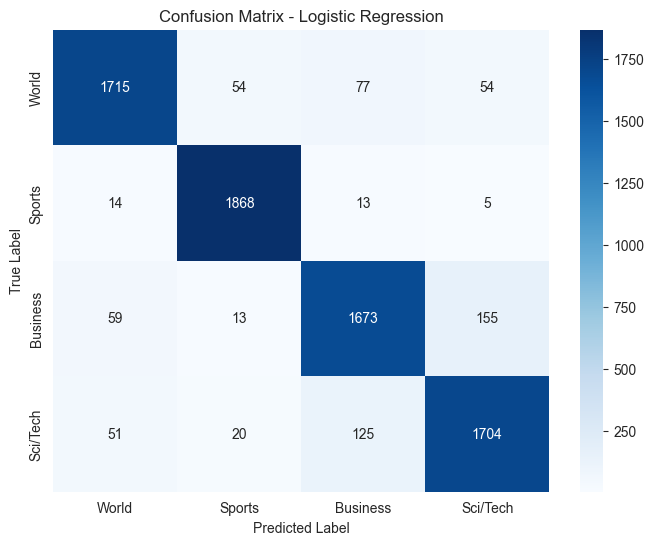


===== Training Naive Bayes =====
📊 Training on 120000 samples with 64675 features...

🔹 Naive Bayes
Accuracy: 0.9043

Classification Report:
              precision    recall  f1-score   support

       World       0.91      0.90      0.90      1900
      Sports       0.95      0.98      0.97      1900
    Business       0.87      0.86      0.87      1900
    Sci/Tech       0.88      0.88      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



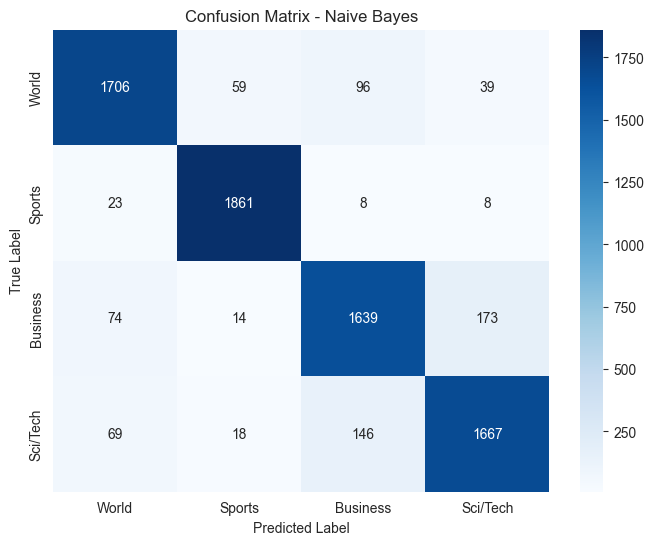


===== Training Random Forest =====
📊 Training on 120000 samples with 64675 features...

🔹 Random Forest
Accuracy: 0.8988

Classification Report:
              precision    recall  f1-score   support

       World       0.92      0.89      0.91      1900
      Sports       0.92      0.98      0.95      1900
    Business       0.87      0.86      0.86      1900
    Sci/Tech       0.88      0.87      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



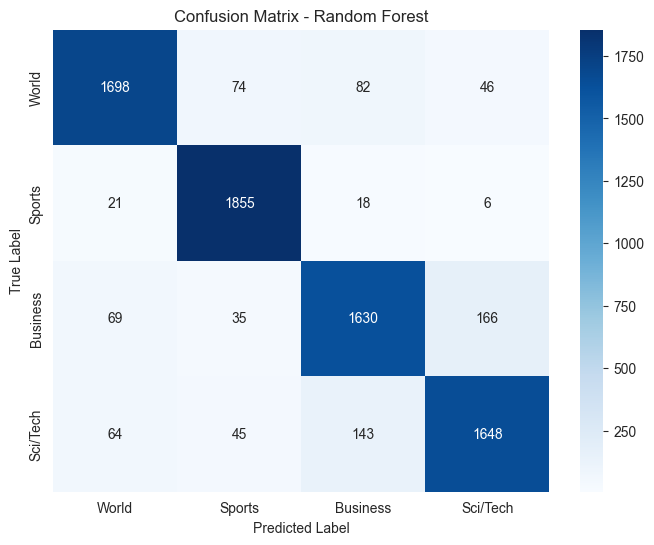


===== Training XGBoost =====
📊 Training on 120000 samples with 64675 features...


D:\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:11:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔹 XGBoost
Accuracy: 0.8905

Classification Report:
              precision    recall  f1-score   support

       World       0.91      0.89      0.90      1900
      Sports       0.93      0.95      0.94      1900
    Business       0.86      0.85      0.86      1900
    Sci/Tech       0.86      0.87      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



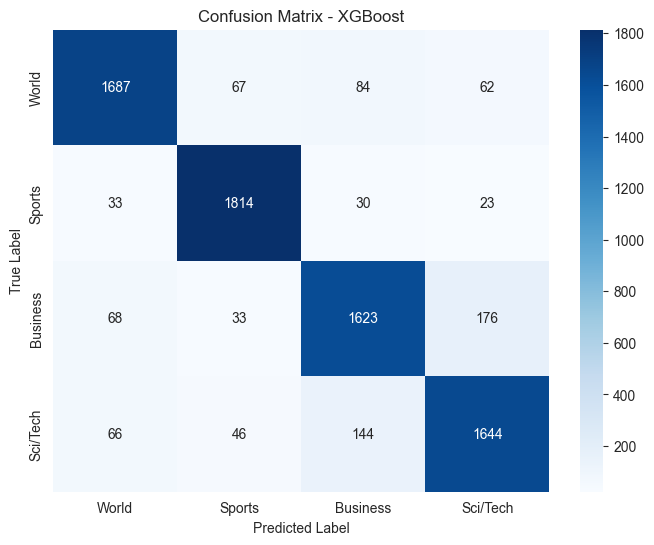


===== Training Decision Tree =====
📊 Training on 120000 samples with 64675 features...

🔹 Decision Tree
Accuracy: 0.8138

Classification Report:
              precision    recall  f1-score   support

       World       0.82      0.82      0.82      1900
      Sports       0.88      0.89      0.88      1900
    Business       0.77      0.77      0.77      1900
    Sci/Tech       0.78      0.77      0.78      1900

    accuracy                           0.81      7600
   macro avg       0.81      0.81      0.81      7600
weighted avg       0.81      0.81      0.81      7600



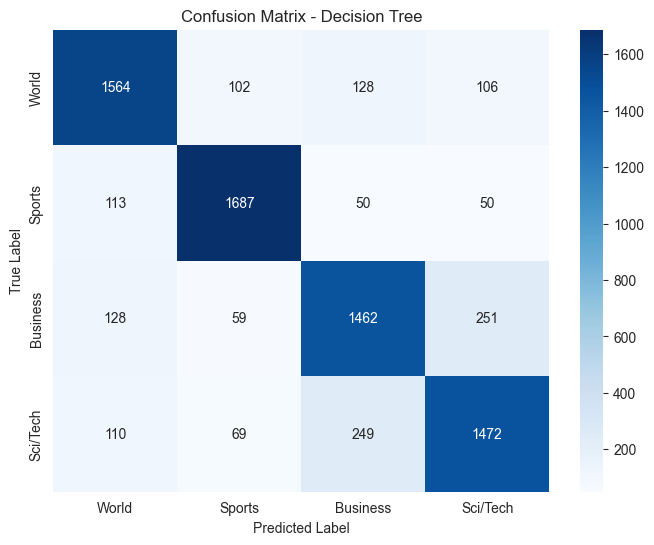


===== Training KNN =====
📊 Training on 120000 samples with 64675 features...

🔹 KNN
Accuracy: 0.9018

Classification Report:
              precision    recall  f1-score   support

       World       0.91      0.90      0.90      1900
      Sports       0.94      0.98      0.96      1900
    Business       0.87      0.87      0.87      1900
    Sci/Tech       0.89      0.86      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



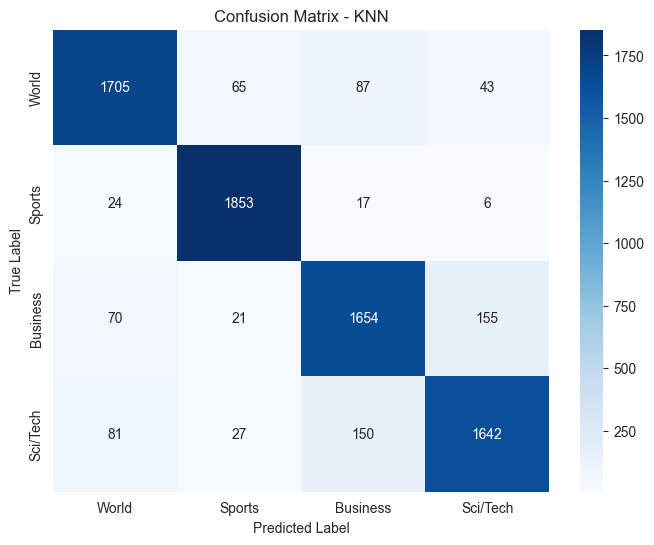


===== Training Gradient Boosting =====
📊 Training on 120000 samples with 64675 features...

🔹 Gradient Boosting
Accuracy: 0.8362

Classification Report:
              precision    recall  f1-score   support

       World       0.88      0.82      0.85      1900
      Sports       0.90      0.89      0.90      1900
    Business       0.81      0.80      0.80      1900
    Sci/Tech       0.76      0.83      0.79      1900

    accuracy                           0.84      7600
   macro avg       0.84      0.84      0.84      7600
weighted avg       0.84      0.84      0.84      7600



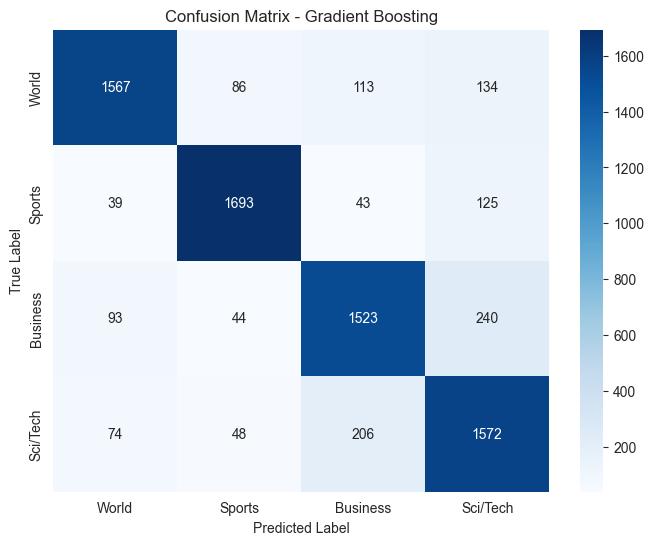


===== Training AdaBoost =====
📊 Training on 120000 samples with 64675 features...

🔹 AdaBoost
Accuracy: 0.5464

Classification Report:
              precision    recall  f1-score   support

       World       0.88      0.37      0.52      1900
      Sports       0.85      0.57      0.68      1900
    Business       0.56      0.48      0.52      1900
    Sci/Tech       0.37      0.77      0.50      1900

    accuracy                           0.55      7600
   macro avg       0.67      0.55      0.56      7600
weighted avg       0.67      0.55      0.56      7600



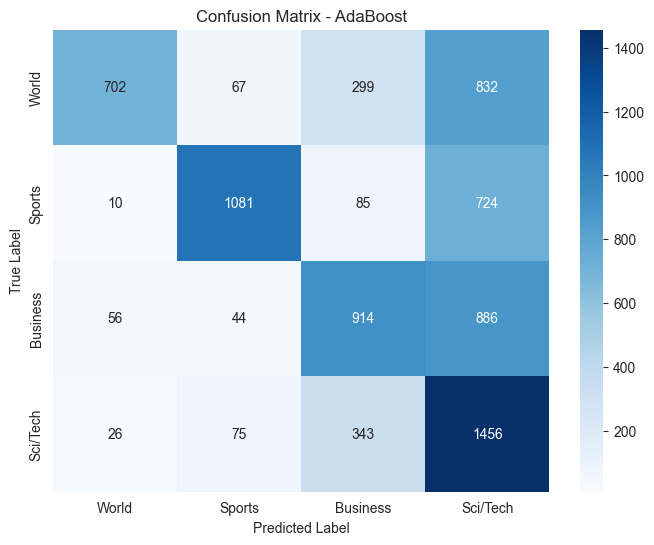


===== Training Extra Trees =====
📊 Training on 120000 samples with 64675 features...

🔹 Extra Trees
Accuracy: 0.9076

Classification Report:
              precision    recall  f1-score   support

       World       0.92      0.90      0.91      1900
      Sports       0.94      0.98      0.96      1900
    Business       0.89      0.86      0.87      1900
    Sci/Tech       0.88      0.88      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



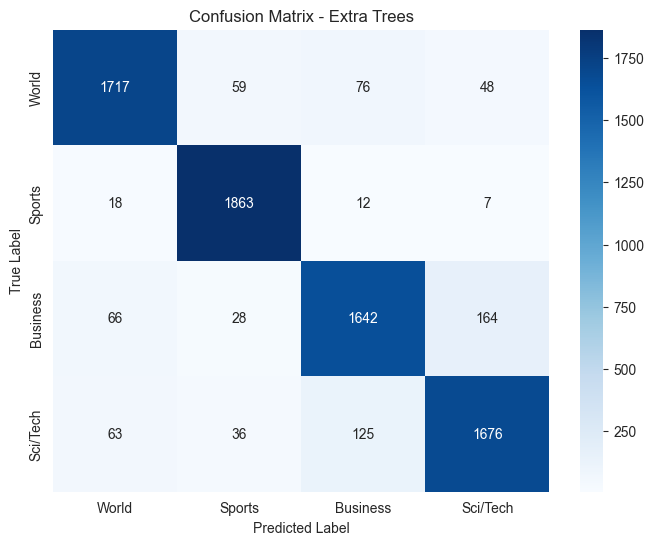


===== Training LightGBM =====
📊 Training on 120000 samples with 64675 features...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.316647 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 600326
[LightGBM] [Info] Number of data points in the train set: 120000, number of used features: 12233
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294

🔹 LightGBM
Accuracy: 0.8959

Classification Report:
              precision    recall  f1-score   support

       World       0.91      0.90      0.90      1900
      Sports       0.93      0.97      0.95      1900
    Business       0.87      0.85      0.86      1900
    Sci/Tech       0.87      0.87      0.87      1900

    accuracy     

D:\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


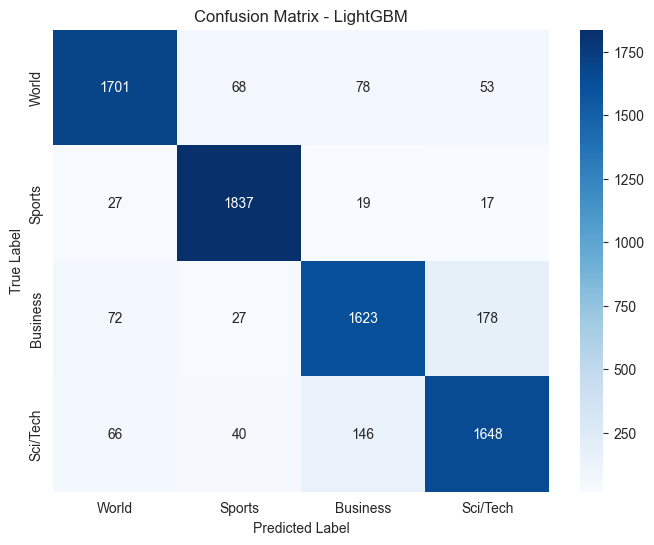


===== Training Passive Aggressive =====
📊 Training on 120000 samples with 64675 features...

🔹 Passive Aggressive
Accuracy: 0.8924

Classification Report:
              precision    recall  f1-score   support

       World       0.90      0.89      0.89      1900
      Sports       0.95      0.96      0.95      1900
    Business       0.85      0.86      0.85      1900
    Sci/Tech       0.87      0.87      0.87      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



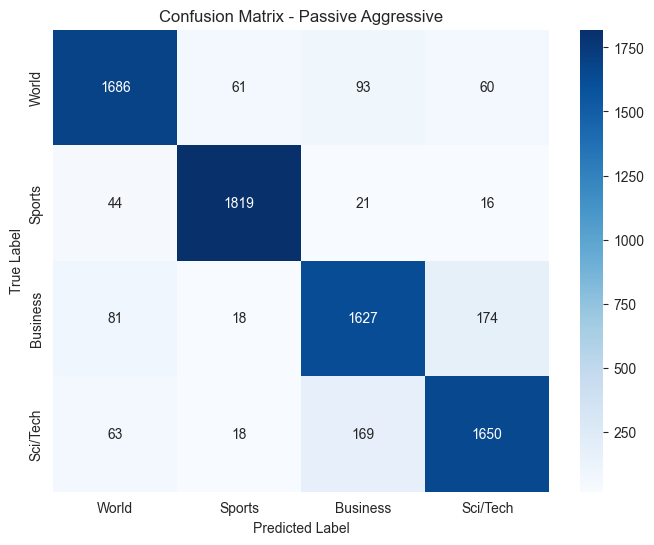

In [12]:
accuracies = {}

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    print(f"📊 Training on {X_train.shape[0]} samples with {X_train.shape[1]} features...")

    model.fit(X_train, y_train)

    acc = evaluate_model(model, X_test, y_test, name)
    accuracies[name] = acc

## 📈 5. Performance Comparison

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19340\1508749860.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')


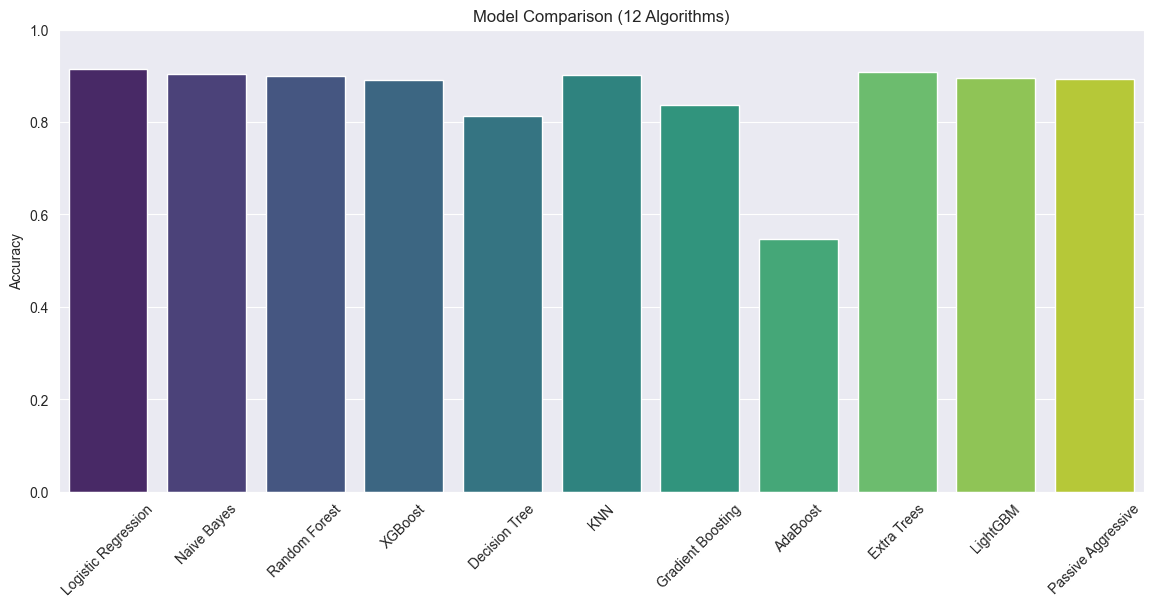

In [13]:
plt.figure(figsize=(14,6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')

plt.xticks(rotation=45)
plt.title("Model Comparison (12 Algorithms)")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19340\2471165340.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')


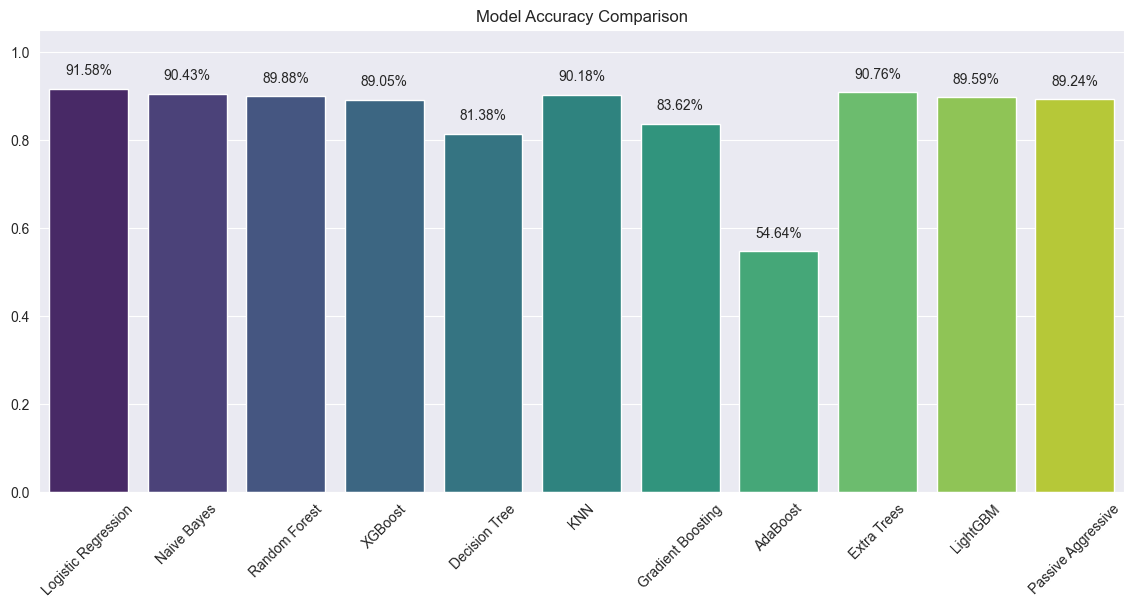

In [14]:
plt.figure(figsize=(14,6))
ax = sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2%}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0,8), textcoords='offset points')

plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylim(0,1.05)
plt.show()